In [16]:
!pip install kaggle wandb onnx -Uq
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
! mkdir ~/.kaggle

mkdir: cannot create directory ‘/root/.kaggle’: File exists


In [18]:
!cp /content/drive/MyDrive/assignment4/kaggle.json ~/.kaggle/kaggle.json

In [19]:
! chmod 600 ~/.kaggle/kaggle.json

In [20]:
! kaggle competitions download challenges-in-representation-learning-facial-expression-recognition-challenge

challenges-in-representation-learning-facial-expression-recognition-challenge.zip: Skipping, found more recently modified local copy (use --force to force download)


In [21]:
! unzip challenges-in-representation-learning-facial-expression-recognition-challenge

Archive:  challenges-in-representation-learning-facial-expression-recognition-challenge.zip
replace example_submission.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [22]:
import torch # Main PyTorch Library
from torch import nn # Used for creating the layers and loss function
from torch.optim import Adam # Adam Optimizer
import torchvision.transforms as transforms # Transform function used to modify and preprocess all the images
from torch.utils.data import Dataset, DataLoader # Dataset class and DataLoader for creating the objects
from sklearn.preprocessing import LabelEncoder # Label Encoder to encode the classes from strings to numbers
import matplotlib.pyplot as plt # Used for visualizing the images and plotting the training progress
from PIL import Image # Used to read the images from the directory
import pandas as pd # Used to read/create dataframes (csv) and process tabular data
import numpy as np # preprocessing and numerical/mathematical operations
import os # Used to read the images path from the directory

device = "cuda" if torch.cuda.is_available() else "cpu" # detect the GPU if any, if not use CPU, change cuda to mps if you have a mac
print("Device available: ", device)

Device available:  cuda


In [23]:

import wandb

wandb.login()

PROJECT = "fer2013-facial-expression"


CONFIG = {
    "architecture": "SimpleCNN",
    "epochs": 30,
    "batch_size": 64,
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "dropout": 0.25,
    "num_classes": 7,
    "img_size": 48,
    "val_split": 0.1,
    "seed": 42,
}

torch.manual_seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


Shape: (28709, 2)
emotion
Angry       3995
Disgust      436
Fear        4097
Happy       7215
Sad         4830
Surprise    3171
Neutral     4965
Name: count, dtype: int64


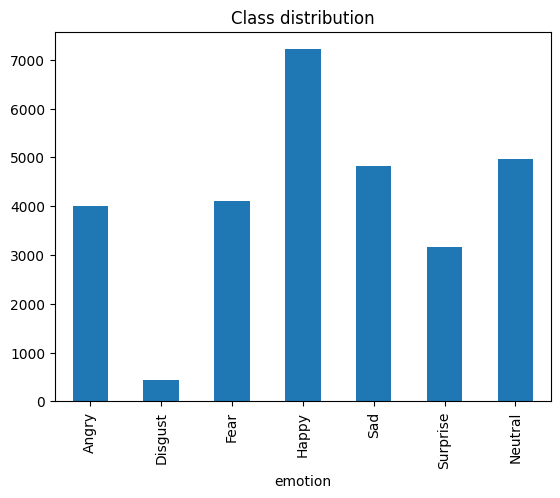

,emotion,pixels
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...
1,0,151 150 147 155 148 133 111 140 170 174 182 15...
2,2,231 212 156 164 174 138 161 173 182 200 106 38...
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...


In [24]:
df = pd.read_csv("train.csv")
print("Shape:", df.shape)

EMOTIONS = {0: "Angry", 1: "Disgust", 2: "Fear", 3: "Happy",4: "Sad", 5: "Surprise", 6: "Neutral"}

counts = df["emotion"].value_counts().sort_index()
print(counts.rename(index=EMOTIONS))
counts.rename(index=EMOTIONS).plot(kind="bar", title="Class distribution"); plt.show()
df.head()


In [25]:
from sklearn.model_selection import train_test_split

le = LabelEncoder()
df["label"] = le.fit_transform(df["emotion"])


train_df, val_df = train_test_split(
    df, test_size=CONFIG["val_split"], random_state=CONFIG["seed"],
    stratify=df["label"],
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
print(f"Train: {len(train_df)} | Val: {len(val_df)}")

Train: 25838 | Val: 2871


In [26]:
class FERDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.pixels = dataframe["pixels"].values
        self.labels = dataframe["label"].values if "label" in dataframe.columns else None
        self.transform = transform

    def __len__(self):
        return len(self.pixels)

    def __getitem__(self, idx):
        pix = np.array(self.pixels[idx].split(), dtype=np.uint8).reshape(48, 48)
        img = Image.fromarray(pix, mode="L")          # 'L' = 8-bit grayscale
        if self.transform:
            img = self.transform(img)
        if self.labels is not None:
            return img, int(self.labels[idx])
        return img


In [27]:
train_tf = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])
eval_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

train_ds = FERDataset(train_df, transform=train_tf)
val_ds   = FERDataset(val_df,   transform=eval_tf)

train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"],
                          shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"],
                          shuffle=False, num_workers=2, pin_memory=True)

print("Train batches:", len(train_loader), "| Val batches:", len(val_loader))

Train batches: 404 | Val batches: 45


In [28]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=7, dropout=0.25):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),   # 48 -> 24
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),   # 24 -> 12
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 12 * 12, 128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

In [29]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()          # backward pass
        optimizer.step()         # update weights
        running_loss += loss.item() * xb.size(0)
        correct += (logits.argmax(1) == yb).sum().item()
        total += xb.size(0)
    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = criterion(logits, yb)
        running_loss += loss.item() * xb.size(0)
        correct += (logits.argmax(1) == yb).sum().item()
        total += xb.size(0)
    return running_loss / total, correct / total

In [30]:
run = wandb.init(
    project=PROJECT,
    name=CONFIG["architecture"],
    config=CONFIG,
    reinit=True,
)

model = SimpleCNN(num_classes=CONFIG["num_classes"], dropout=CONFIG["dropout"]).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=CONFIG["lr"], weight_decay=CONFIG["weight_decay"])

wandb.watch(model, criterion, log="all", log_freq=100)

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = 0.0

for epoch in range(CONFIG["epochs"]):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    history["train_loss"].append(tr_loss); history["train_acc"].append(tr_acc)
    history["val_loss"].append(val_loss);  history["val_acc"].append(val_acc)

    wandb.log({
        "epoch": epoch,
        "train_loss": tr_loss, "train_acc": tr_acc,
        "val_loss": val_loss,  "val_acc": val_acc,
        "lr": optimizer.param_groups[0]["lr"],
    })
    print(f"Epoch {epoch+1:02d}/{CONFIG['epochs']}"
          f"train_loss {tr_loss:.4f} acc {tr_acc:.4f}"
          f"val_loss {val_loss:.4f} acc {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pt")

wandb.summary["best_val_acc"] = best_val_acc
print("Best val accuracy:", best_val_acc)

/tmp/ipykernel_2710/656374988.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(pix, mode="L")          # 'L' = 8-bit grayscale
/tmp/ipykernel_2710/656374988.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(pix, mode="L")          # 'L' = 8-bit grayscale
/tmp/ipykernel_2710/656374988.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(pix, mode="L")          # 'L' = 8-bit grayscale
/tmp/ipykernel_2710/656374988.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(pix, mode="L")          # 'L' = 8-bit grayscale


Epoch 01/30train_loss 1.7189 acc 0.3106val_loss 1.5313 acc 0.3932


/tmp/ipykernel_2710/656374988.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(pix, mode="L")          # 'L' = 8-bit grayscale
/tmp/ipykernel_2710/656374988.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(pix, mode="L")          # 'L' = 8-bit grayscale
/tmp/ipykernel_2710/656374988.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(pix, mode="L")          # 'L' = 8-bit grayscale
/tmp/ipykernel_2710/656374988.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(pix, mode="L")          # 'L' = 8-bit grayscale


Epoch 02/30train_loss 1.5708 acc 0.3777val_loss 1.4644 acc 0.4323


/tmp/ipykernel_2710/656374988.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(pix, mode="L")          # 'L' = 8-bit grayscale
/tmp/ipykernel_2710/656374988.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(pix, mode="L")          # 'L' = 8-bit grayscale
/tmp/ipykernel_2710/656374988.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(pix, mode="L")          # 'L' = 8-bit grayscale
/tmp/ipykernel_2710/656374988.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(pix, mode="L")          # 'L' = 8-bit grayscale


...

Epoch 28/30train_loss 1.1923 acc 0.5408val_loss 1.1473 acc 0.5653


/tmp/ipykernel_2710/656374988.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(pix, mode="L")          # 'L' = 8-bit grayscale
/tmp/ipykernel_2710/656374988.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(pix, mode="L")          # 'L' = 8-bit grayscale
/tmp/ipykernel_2710/656374988.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(pix, mode="L")          # 'L' = 8-bit grayscale
/tmp/ipykernel_2710/656374988.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(pix, mode="L")          # 'L' = 8-bit grayscale


Epoch 29/30train_loss 1.1817 acc 0.5434val_loss 1.1476 acc 0.5674


/tmp/ipykernel_2710/656374988.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(pix, mode="L")          # 'L' = 8-bit grayscale
/tmp/ipykernel_2710/656374988.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(pix, mode="L")          # 'L' = 8-bit grayscale
/tmp/ipykernel_2710/656374988.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(pix, mode="L")          # 'L' = 8-bit grayscale
/tmp/ipykernel_2710/656374988.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(pix, mode="L")          # 'L' = 8-bit grayscale


Epoch 30/30train_loss 1.1702 acc 0.5516val_loss 1.1437 acc 0.5622
Best val accuracy: 0.567398119122257


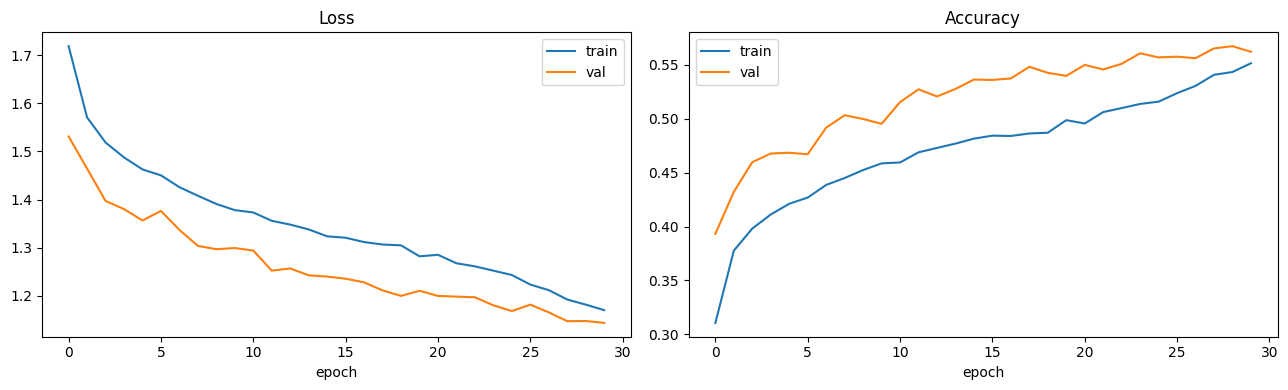

Best val: 0.5674
Final train-val accuracy gap: -0.0106


In [31]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(history["train_loss"], label="train")
ax1.plot(history["val_loss"], label="val")
ax1.set_title("Loss"); ax1.set_xlabel("epoch"); ax1.legend()

ax2.plot(history["train_acc"], label="train")
ax2.plot(history["val_acc"], label="val")
ax2.set_title("Accuracy"); ax2.set_xlabel("epoch"); ax2.legend()
plt.tight_layout(); plt.show()

print(f"Best val: {best_val_acc:.4f}")
print(f"Final train-val accuracy gap: {history['train_acc'][-1] - history['val_acc'][-1]:.4f}")

/tmp/ipykernel_2710/656374988.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(pix, mode="L")          # 'L' = 8-bit grayscale
/tmp/ipykernel_2710/656374988.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(pix, mode="L")          # 'L' = 8-bit grayscale


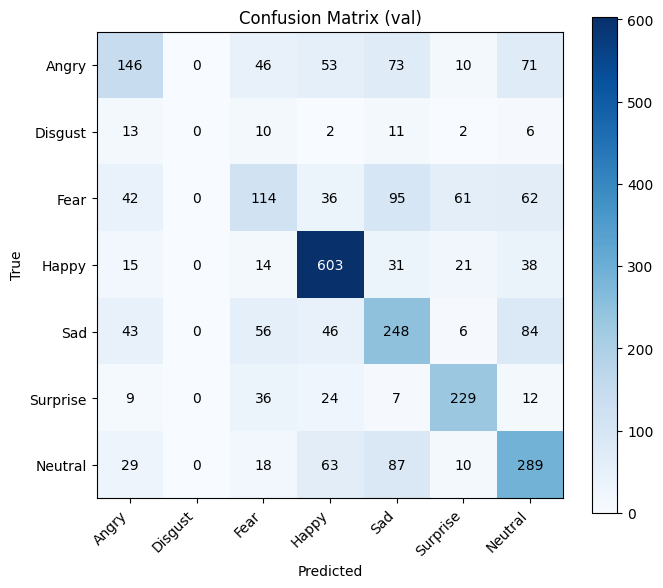

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

       Angry       0.49      0.37      0.42       399
     Disgust       0.00      0.00      0.00        44
        Fear       0.39      0.28      0.32       410
       Happy       0.73      0.84      0.78       722
         Sad       0.45      0.51      0.48       483
    Surprise       0.68      0.72      0.70       317
     Neutral       0.51      0.58      0.55       496

    accuracy                           0.57      2871
   macro avg       0.46      0.47      0.46      2871
weighted avg       0.55      0.57      0.55      2871



In [32]:
from sklearn.metrics import confusion_matrix, classification_report

model.load_state_dict(torch.load("best_model.pt", map_location=device))
model.eval()

all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb in val_loader:
        logits = model(xb.to(device))
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_true.extend(yb.numpy())

cm = confusion_matrix(all_true, all_preds)
class_names = [EMOTIONS[c] for c in le.classes_]

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(class_names))); ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticks(range(len(class_names))); ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title("Confusion Matrix (val)")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
fig.colorbar(im); plt.tight_layout(); plt.show()

print(classification_report(all_true, all_preds, target_names=class_names))


wandb.log({"val_confusion_matrix": wandb.plot.confusion_matrix(y_true=all_true, preds=all_preds, class_names=class_names)})


In [33]:
test_df = pd.read_csv("test.csv")
print("Test samples:", len(test_df))

test_ds = FERDataset(test_df, transform=eval_tf)   # no labels -> returns images only
test_loader = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False)

# Load the best weights saved during training before predicting.
model.load_state_dict(torch.load("best_model.pt", map_location=device))
model.eval()

preds = []
with torch.no_grad():
    for xb in test_loader:
        xb = xb.to(device)
        logits = model(xb)
        preds.extend(logits.argmax(1).cpu().numpy().tolist())


emotion_preds = le.inverse_transform(np.array(preds))
submission = pd.DataFrame({"emotion": emotion_preds})
submission.index.name = "id"
submission.to_csv("submission.csv")
print("Wrote submission.csv")
submission.head()

Test samples: 7178


/tmp/ipykernel_2710/656374988.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(pix, mode="L")          # 'L' = 8-bit grayscale


Wrote submission.csv


,emotion
id,
0,0
1,2
2,0
3,4
4,3
